In [9]:
!pip install ucimlrepo

In [12]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
facebook_live_sellers_in_thailand = fetch_ucirepo(id=488)

# data (as pandas dataframes)
X = facebook_live_sellers_in_thailand.data.features
y = facebook_live_sellers_in_thailand.data.targets

# metadata
print(facebook_live_sellers_in_thailand.metadata)

# variable information
print(facebook_live_sellers_in_thailand.variables)


{'uci_id': 488, 'name': 'Facebook Live Sellers in Thailand', 'repository_url': 'https://archive.ics.uci.edu/dataset/488/facebook+live+sellers+in+thailand', 'data_url': 'https://archive.ics.uci.edu/static/public/488/data.csv', 'abstract': 'Facebook pages of 10 Thai fashion and cosmetics retail sellers. Posts of a different nature (video, photos, statuses, and links). Engagement metrics consist of comments, shares, and reactions.', 'area': 'Business', 'tasks': ['Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 7051, 'num_features': 11, 'feature_types': ['Integer'], 'demographics': [], 'target_col': None, 'index_col': ['status_id'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2018, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C5R60S', 'creators': ['Nassim Dehouche'], 'intro_paper': {'ID': 454, 'type': 'NATIVE', 'title': 'Dataset on usage and engagement patterns for Facebook Live sellers in Thailand', 'authors': '

In [16]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

df = X.copy()

# Drop ID
df = df.drop(columns=['status_id'], errors='ignore')

# Convert datetime → extract features
df['status_published'] = pd.to_datetime(df['status_published'])
df['hour'] = df['status_published'].dt.hour
df['day'] = df['status_published'].dt.dayofweek
df = df.drop(columns=['status_published'])

# Separate categorical & numerical
categorical_cols = ['status_type']
numerical_cols = [col for col in df.columns if col not in categorical_cols]

# ColumnTransformer with OneHotEncoder
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
])

# Transform data
scaled_data = preprocessor.fit_transform(df)

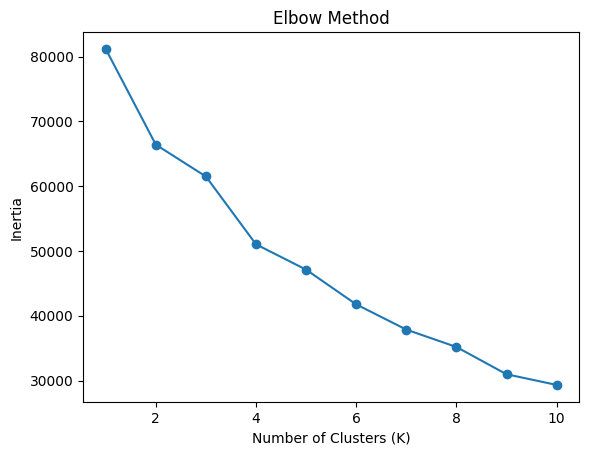

In [17]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

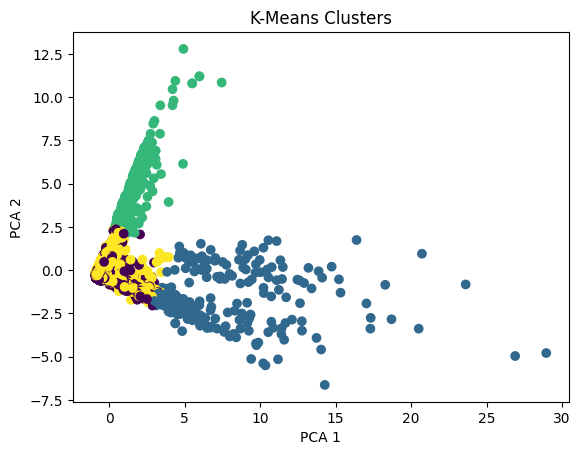

         num_reactions  num_comments  num_shares    num_likes   num_loves  \
Cluster                                                                     
0           108.818975    105.255180   20.454380   100.599418    7.131952   
1           785.981550   3253.464945  511.712177   604.904059  149.778598   
2          1848.861496     62.551247   11.783934  1843.036011    3.119114   
3           120.677666    105.776657   22.623671   111.818926    7.745023   

          num_wows  num_hahas  num_sads  num_angrys      hour       day  
Cluster                                                                  
0         0.552890   0.346419  0.126499    0.059251  7.815703  0.988731  
1        17.191882   9.715867  2.767528    1.623616  7.210332  2.974170  
2         2.468144   0.199446  0.033241    0.005540  8.673130  3.055402  
3         0.550586   0.341424  0.165803    0.052632  7.802563  4.534224  


In [27]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Choose K from elbow
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# PCA
pca = PCA(n_components=3)
pca_data = pca.fit_transform(scaled_data)

import matplotlib.pyplot as plt

plt.scatter(pca_data[:, 0], pca_data[:, 1], c=clusters)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('K-Means Clusters')
plt.show()

# Add cluster labels back
df['Cluster'] = clusters
print(df.groupby('Cluster').mean(numeric_only=True))

###  K-Means Clustering Insights (Facebook Live Sellers Dataset)

1. **Cluster 1 – Viral / Highly Engaging Posts**  
   This cluster shows extremely high comments, shares, and reactions, indicating highly engaging posts. These are likely live videos, promotions, or interactive content that encourage strong user participation and sharing.

2. **Cluster 2 – Passive Popular Posts (Like-Dominated)**  
   This cluster has very high likes but low comments and shares. It represents passive engagement where users react but do not actively interact. These are typically product images or visually appealing posts.

3. **Cluster 0 – Average Engagement Posts**  
   Posts in this cluster have balanced but moderate values across reactions, comments, and shares. They represent standard content with average performance.

4. **Cluster 3 – Timing-Influenced Moderate Posts**  
   Similar to average engagement posts but with differences in posting day, suggesting that timing (especially day of the week) influences engagement despite similar content.

5. **Overall Insight**  
   The clustering reveals four key post types: **Viral, Passive, Average, and Timing-Influenced**, showing that content type and interaction style are the primary drivers of engagement, with timing playing a secondary role.